# Oscillon MG — Post-run analysis

Read simulation data produced by `RunScripts/run_oscillon.py` and plot
oscillon diagnostics (compactness, density contrast, energy-density profiles).

Each run lives in a subfolder of `$VSC_DATA/oscillon_runs/`, named by its parameter tag.

In [23]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
print(f"DATA_DIR = {DATA_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs


## 1 — Discover available runs

In [24]:
run_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_DIR, "lgb*"))
    if os.path.isdir(d) and os.path.exists(os.path.join(d, "solution.npy"))
])

print(f"Found {len(run_dirs)} run(s) with data:")
for d in run_dirs:
    tag = os.path.basename(d)
    meta_path = os.path.join(d, "metadata.npz")
    status = "complete"
    if os.path.exists(meta_path):
        meta = dict(np.load(meta_path, allow_pickle=True))
        if "solver_success" in meta and not bool(meta["solver_success"]):
            t_crash = float(meta.get("t_crash", -1))
            status = f"CRASHED at t ≈ {t_crash:.1f}"
    print(f"  {tag}  [{status}]")

Found 14 run(s) with data:
  lgb0.0_mu0.04_a0.2_b0.4_amp-0.02_R3_dr0.0625  [complete]
  lgb0.0_mu0.06_a0.2_b0.4_amp-0.02_R3_dr0.0625  [complete]
  lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625  [complete]
  lgb10.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625  [complete]
  lgb2.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_10  [complete]
  lgb2.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_50  [complete]
  lgb2.0_mu0.08_a0.2_b0.4_amp-0.05_R3_dr0.0625_quadratic_50  [complete]
  lgb20.0_mu0.04_a0.2_b0.4_amp-0.02_R3_dr0.0625  [CRASHED at t ≈ 39.7]
  lgb20.0_mu0.06_a0.2_b0.4_amp-0.02_R3_dr0.0625  [complete]
  lgb20.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625  [complete]
  lgb5.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625  [complete]
  lgb5.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_10  [complete]
  lgb5.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_25  [complete]
  lgb5.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_50  [complete]


## 2 — Load data and compute diagnostics

In [25]:
# Default physics parameters (must match what was used in run_oscillon.py)
scalar_mu = 1
selfinteraction = 0.08
chi0 = 0.15
coupling = "quadratic"
a_mg = 0.2
b_mg = 0.4

r_max = 150
min_dr = 1 / 16
max_dr = 2

# Reconstruct grid (same for all runs with these grid params)
matter_ref = ScalarMatter(scalar_mu, selfinteraction)
sv_ref = StateVector(matter_ref)
spacing_ref = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
grid_ref = Grid(spacing_ref, sv_ref)
bg_ref = FlatSphericalBackground(grid_ref.r)

print(f"Grid: {grid_ref.r.size} points,  r in [{grid_ref.r[0]:.4f}, {grid_ref.r[-1]:.1f}]")

Grid: 216 points,  r in [-0.1559, 150.0]


In [26]:
results = {}  # lgb_value -> dict with 'osc', 't', 'tag', 'run_dir', 'crashed', 't_crash'

for run_dir in run_dirs:
    tag = os.path.basename(run_dir)

    lgb = float(tag.split("_")[0].replace("lgb", ""))

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    crashed = False
    t_crash = -1.0
    meta_path = os.path.join(run_dir, "metadata.npz")
    if os.path.exists(meta_path):
        meta = dict(np.load(meta_path, allow_pickle=True))
        if "solver_success" in meta and not bool(meta["solver_success"]):
            crashed = True
            t_crash = float(meta.get("t_crash", t[-1]))

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
        status = "loaded pre-computed diagnostics"
    else:
        status = "computing diagnostics ..."
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_ref, bg_ref,
            ScalarMatter(scalar_mu, selfinteraction),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(os.path.join(run_dir, "diagnostics.npz"), **osc)

    crash_note = f"  [CRASHED at t ≈ {t_crash:.1f}]" if crashed else ""
    print(f"lgb={lgb} — {status}{crash_note}")

    results[lgb] = dict(osc=osc, t=t, tag=tag, run_dir=run_dir,
                        crashed=crashed, t_crash=t_crash)
    C_max = np.max(osc["C"])
    print(f"  lgb={lgb:.3f}  max compactness C = {C_max:.6e}  ({len(t)} time steps)")

    del sol

lgb=0.0 — loaded pre-computed diagnostics
  lgb=0.000  max compactness C = 1.200647e+00  (2000 time steps)
lgb=0.0 — loaded pre-computed diagnostics
  lgb=0.000  max compactness C = 2.594224e+00  (2000 time steps)
lgb=0.0 — loaded pre-computed diagnostics
  lgb=0.000  max compactness C = 4.439620e+00  (2750 time steps)
lgb=10.0 — loaded pre-computed diagnostics
  lgb=10.000  max compactness C = 4.439620e+00  (1000 time steps)
lgb=2.0 — loaded pre-computed diagnostics
  lgb=2.000  max compactness C = 4.439620e+00  (1000 time steps)
lgb=2.0 — loaded pre-computed diagnostics
  lgb=2.000  max compactness C = 4.439620e+00  (1000 time steps)
lgb=2.0 — loaded pre-computed diagnostics
  lgb=2.000  max compactness C = 4.439699e+00  (1000 time steps)
lgb=20.0 — loaded pre-computed diagnostics  [CRASHED at t ≈ 39.7]
  lgb=20.000  max compactness C = 1.200647e+00  (50 time steps)
lgb=20.0 — loaded pre-computed diagnostics
  lgb=20.000  max compactness C = 2.594224e+00  (1000 time steps)
lgb=20.0 —

## 3 — Compactness vs $\lambda_{\rm GB}$

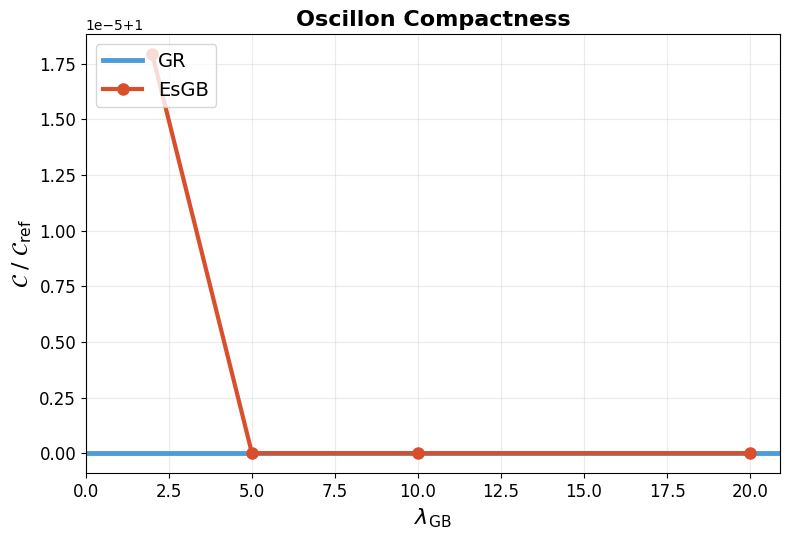

In [27]:
lambdas_sorted = np.array(sorted(results.keys()))
C_max_vals = np.array([np.max(results[l]["osc"]["C"]) for l in lambdas_sorted])

# Normalise to GR if available, otherwise to first run
C_ref = C_max_vals[0] if 0.0 in results else C_max_vals[0]
if 0.0 in results:
    C_ref = np.max(results[0.0]["osc"]["C"])
C_norm = C_max_vals / C_ref

fig, ax = plt.subplots(figsize=(8, 5.5))

if 0.0 in results:
    ax.axhline(1.0, color="#4E9BD9", lw=3.5, label="GR", zorder=2)
    mg_mask = lambdas_sorted > 0
else:
    mg_mask = np.ones_like(lambdas_sorted, dtype=bool)

ax.plot(lambdas_sorted[mg_mask], C_norm[mg_mask],
        "o-", color="#D94E2B", lw=3, ms=8, zorder=3, label="EsGB")

ax.set_xlabel(r"$\lambda_{\rm GB}$", fontsize=16)
ax.set_ylabel(r"$\mathcal{C}\;/\;\mathcal{C}_{\rm ref}$", fontsize=16)
ax.set_title("Oscillon Compactness", fontsize=16, fontweight="bold")
ax.legend(fontsize=14, loc="upper left")
ax.tick_params(labelsize=12)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 4 — Compactness time series

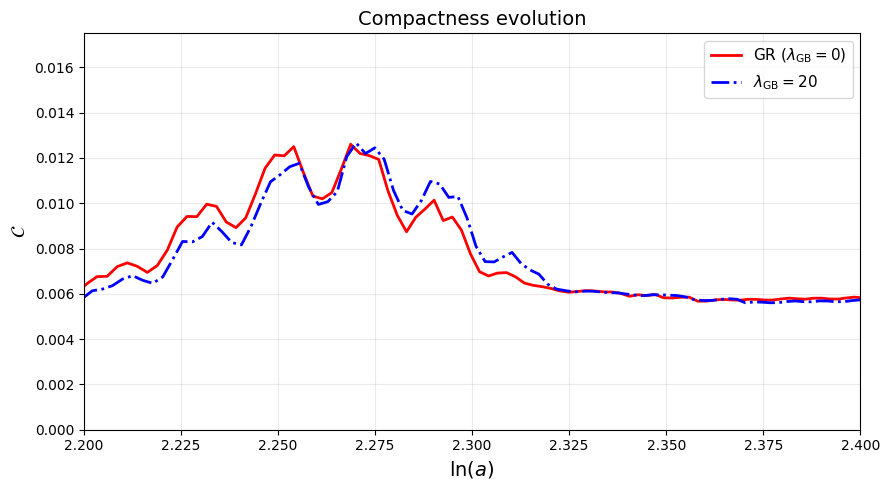

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

indexer = 500 
#couplingz = results.keys()
couplingz = np.array([0,20])

#colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(results)))
colors = ['red', 'blue']
linestyle = ["-", "-.", "-.", "--", "-"]

#for i, lgb in enumerate(sorted(results.keys())):
for i, lgb in enumerate(sorted(couplingz)):
    osc = results[lgb]["osc"]
    label = f"$\\lambda_{{\\rm GB}}={lgb}$"
    if lgb == 0.0:
        label = r"GR ($\lambda_{\rm GB}=0$)"
    ax.plot(osc["ln_a"], osc["C"] ,
            color=colors[i], lw=2, label=label, linestyle=linestyle[i])

ax.set_xlabel(r"$\ln(a)$", fontsize=14)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=14)
ax.set_title("Compactness evolution", fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(2.2, 2.4)
ax.set_ylim(0, 0.0175)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

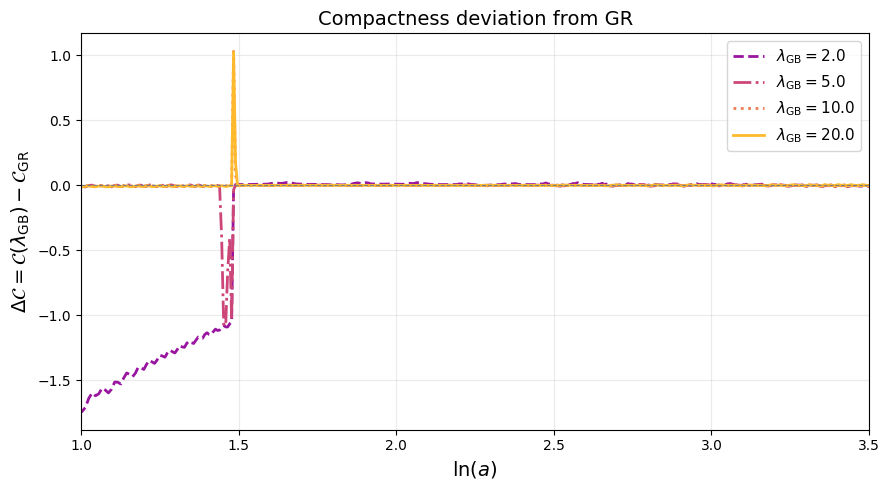

In [29]:
# Residual plot: C(lgb) - C(GR) to reveal the effect of lambda_GB
if 0.0 in results:
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(results)))
    linestyle = ["-", "--", "-.", ":", "-"]

    C_gr = results[0.0]["osc"]["C"]
    ln_a_gr = results[0.0]["osc"]["ln_a"]

    for i, lgb in enumerate(sorted(results.keys())):
        if lgb == 0.0:
            continue
        osc = results[lgb]["osc"]
        C_mg = osc["C"]
        ln_a_mg = osc["ln_a"]

        # Interpolate onto the GR time grid if lengths differ
        if len(C_mg) != len(C_gr):
            C_mg = np.interp(ln_a_gr, ln_a_mg, C_mg)

        delta_C = C_mg - C_gr
        label = f"$\\lambda_{{\\rm GB}}={lgb}$"
        ax.plot(ln_a_gr, delta_C,
                color=colors[i], lw=2, label=label, linestyle=linestyle[i % len(linestyle)])

    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel(r"$\ln(a)$", fontsize=14)
    ax.set_ylabel(r"$\Delta\mathcal{C} = \mathcal{C}(\lambda_{\rm GB}) - \mathcal{C}_{\rm GR}$", fontsize=14)
    ax.set_title("Compactness deviation from GR", fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xlim(1, 3.5)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    print("No GR (lgb=0) run found — cannot compute residuals.")

## 5 — Density contrast evolution

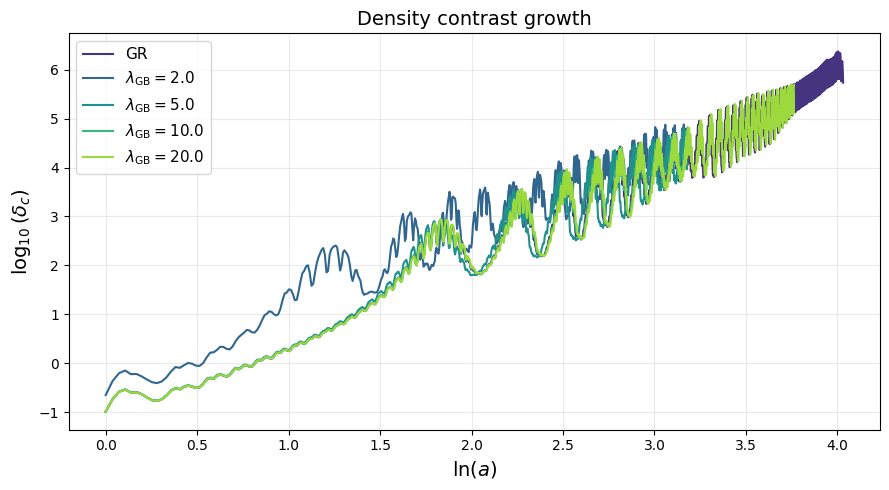

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(results)))

for i, lgb in enumerate(sorted(results.keys())):
    osc = results[lgb]["osc"]
    dc = osc["delta_c"]
    pos = dc > 0
    y = np.full_like(dc, np.nan)
    y[pos] = np.log10(dc[pos])

    label = f"$\\lambda_{{\\rm GB}}={lgb}$"
    if lgb == 0.0:
        label = r"GR"
    ax.plot(osc["ln_a"], y, color=colors[i], lw=1.5, label=label)

ax.set_xlabel(r"$\ln(a)$", fontsize=14)
ax.set_ylabel(r"$\log_{10}(\delta_c)$", fontsize=14)
ax.set_title("Density contrast growth", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 6 — Central density and Hubble rate

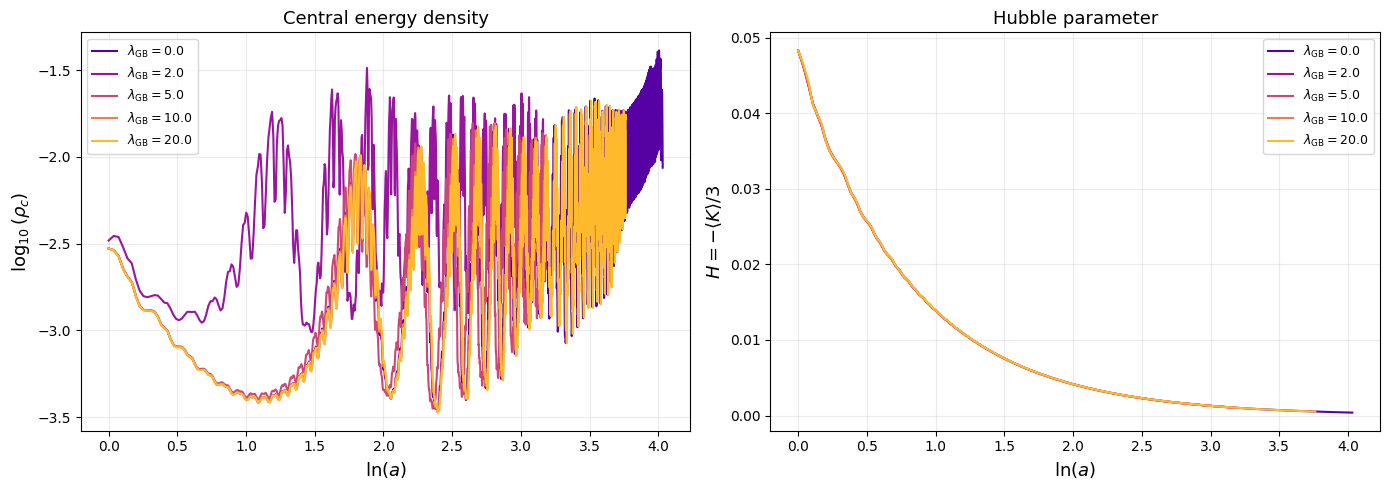

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(results)))

for i, lgb in enumerate(sorted(results.keys())):
    osc = results[lgb]["osc"]
    label = f"$\\lambda_{{\\rm GB}}={lgb}$"

    # Central density
    rc = osc["rho_c"]
    pos = rc > 0
    y = np.full_like(rc, np.nan)
    y[pos] = np.log10(rc[pos])
    axes[0].plot(osc["ln_a"], y, color=colors[i], lw=1.5, label=label)

    # Hubble rate
    H = -osc["K_avg"] / 3.0
    axes[1].plot(osc["ln_a"], H, color=colors[i], lw=1.5, label=label)

axes[0].set_xlabel(r"$\ln(a)$", fontsize=13)
axes[0].set_ylabel(r"$\log_{10}(\rho_c)$", fontsize=13)
axes[0].set_title("Central energy density", fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25)

axes[1].set_xlabel(r"$\ln(a)$", fontsize=13)
axes[1].set_ylabel(r"$H = -\langle K \rangle / 3$", fontsize=13)
axes[1].set_title("Hubble parameter", fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

## 7 — Full diagnostic panels (single run)

Select a specific run by its `lambda_GB` value to see the four-panel diagnostic figure.

Showing diagnostics for lambda_GB = 20.0, mu = 0.08


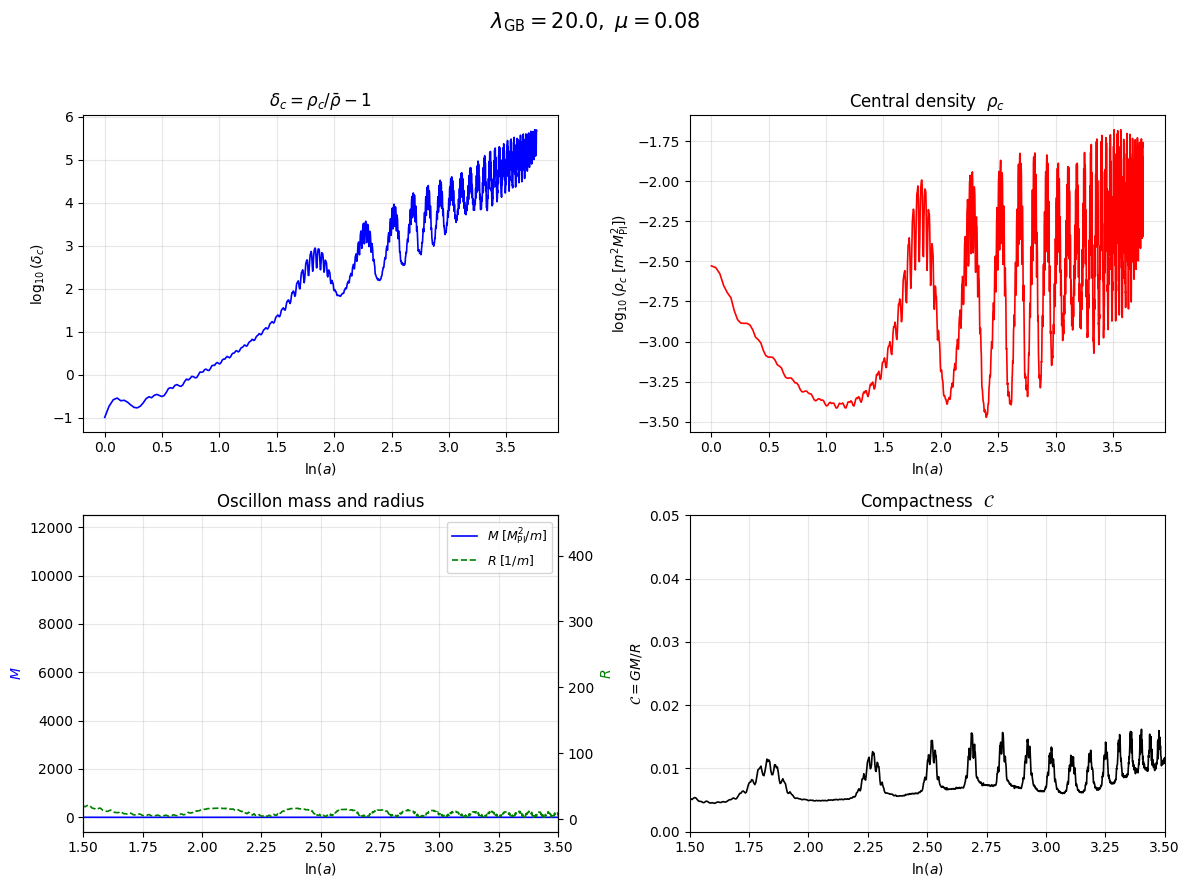

In [32]:
from bssn.oscillondiagnostic import plot_paper_diagnostics

# Pick a run to inspect in detail — choose lgb and mu here
lgb_inspect = 20.0
mu_inspect  = 0.08

# Works with both the single-mu 'results' dict and multi-mu 'all_results' dict
if "all_results" in dir() and all_results:
    key_inspect = (lgb_inspect, mu_inspect)
    if key_inspect in all_results:
        osc_data = all_results[key_inspect]["osc"]
    else:
        print(f"No run found for lgb={lgb_inspect}, mu={mu_inspect}")
        print(f"Available: {sorted(all_results.keys())}")
        osc_data = None
elif "results" in dir() and lgb_inspect in results:
    osc_data = results[lgb_inspect]["osc"]
    print(f"(Using single-mu results dict, mu selection ignored)")
else:
    print("No data loaded. Run the loading cells first.")
    osc_data = None

if osc_data is not None:
    print(f"Showing diagnostics for lambda_GB = {lgb_inspect}, mu = {mu_inspect}")
    fig, axes = plot_paper_diagnostics(osc_data)
    fig.suptitle(rf"$\lambda_{{\rm GB}} = {lgb_inspect},\ \mu = {mu_inspect}$", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# 7.5 Hyperbolicity

No NER — system remains hyperbolic throughout.


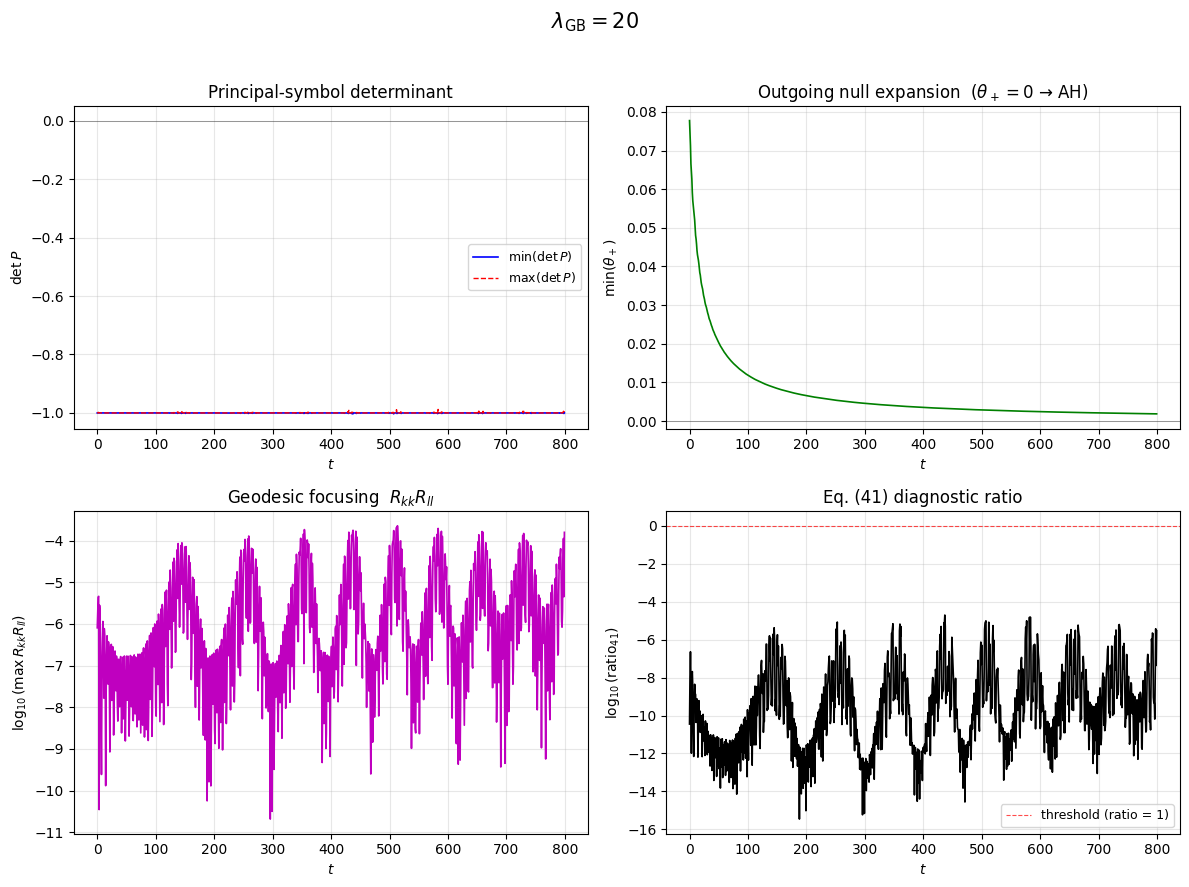

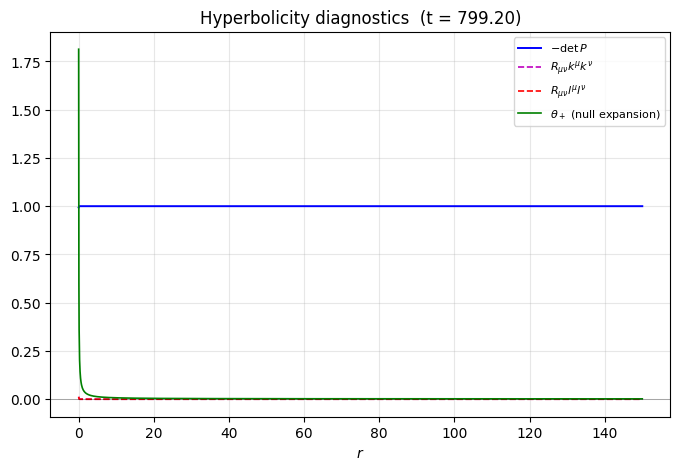

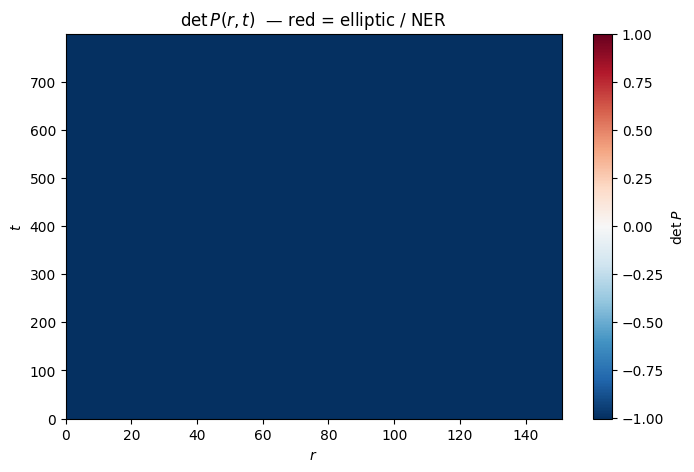

In [20]:
from bssn.hyperbolicitydiagnostic import (get_hyperbolicity_diagnostic,
                                          plot_hyperbolicity_diagnostics,
                                          plot_hyperbolicity_snapshot,
                                          plot_det_P_spacetime)

# Set the coupling constant (lambda_GB) you want to inspect:
lgb_inspect = 20  # e.g. 0, 5, 10, 20, 25 — must be a key in results

if lgb_inspect not in results:
    print(f"No data for λ_GB = {lgb_inspect}. Available couplings: {sorted(results.keys())}")
else:
    run_dir_hyp = results[lgb_inspect]["run_dir"]
    sol_hyp = np.load(os.path.join(run_dir_hyp, "solution.npy"))
    t_hyp = results[lgb_inspect]["t"]
    params_hyp = (lgb_inspect, a_mg, b_mg, chi0, coupling)

    hyp = get_hyperbolicity_diagnostic(sol_hyp, t_hyp, grid_ref, bg_ref,
                                        ScalarMatter(scalar_mu, selfinteraction),
                                        params_hyp)

    if np.any(hyp["det_P"] >= 0):
        print("NER detected!")
    else:
        print("No NER — system remains hyperbolic throughout.")

    fig, axes = plot_hyperbolicity_diagnostics(hyp)
    fig.suptitle(rf"$\lambda_{{\rm GB}} = {lgb_inspect}$", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    plot_hyperbolicity_snapshot(hyp, time_idx=-1)
    plt.show()

    plot_det_P_spacetime(hyp)
    plt.show()

    del sol_hyp

## 8 — Energy-density radial profiles

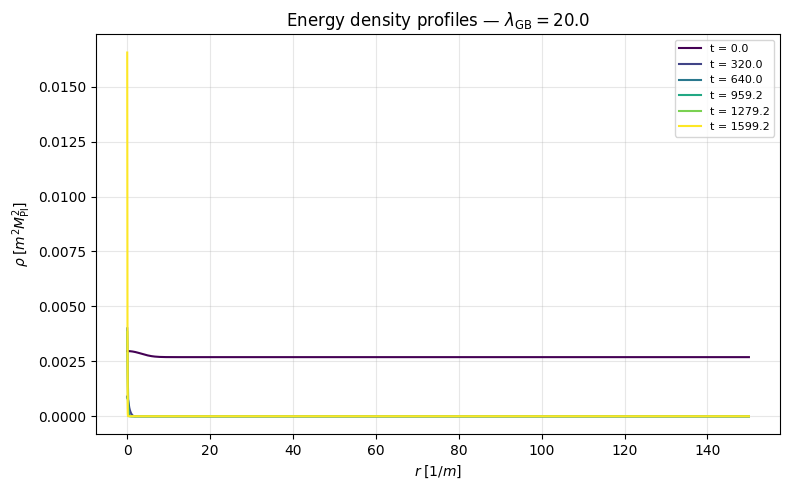

In [33]:
from bssn.oscillondiagnostic import plot_density_profiles_at_times

# Reload the full solution for the selected run to make spatial profiles
run_dir_inspect = results[lgb_inspect]["run_dir"]
sol_inspect = np.load(os.path.join(run_dir_inspect, "solution.npy"))
t_inspect = results[lgb_inspect]["t"]

params_inspect = (lgb_inspect, a_mg, b_mg, chi0, coupling)
osc_inspect = get_oscillon_diagnostic(
    sol_inspect, t_inspect, grid_ref, bg_ref,
    ScalarMatter(scalar_mu, selfinteraction),
    params_inspect, surface_threshold=0.05, r_max_diag=100.0,
)

fig, ax = plt.subplots(figsize=(8, 5))
plot_density_profiles_at_times(osc_inspect, ax=ax)
ax.set_title(rf"Energy density profiles — $\lambda_{{\rm GB}} = {lgb_inspect}$")
fig.tight_layout()
plt.show()

del sol_inspect

## Summary table

In [34]:
print(f"{'lambda_GB':>12s}  {'C_max':>12s}  {'C/C_ref':>10s}")
print("-" * 38)
for lgb in sorted(results.keys()):
    Cmax = np.max(results[lgb]["osc"]["C"])
    ratio = Cmax / C_ref
    print(f"{lgb:12.4f}  {Cmax:12.6e}  {ratio:10.4f}")

   lambda_GB         C_max     C/C_ref
--------------------------------------
      0.0000  4.439620e+00      1.0000
      2.0000  4.439699e+00      1.0000
      5.0000  4.439620e+00      1.0000
     10.0000  4.439620e+00      1.0000
     20.0000  4.439620e+00      1.0000


In [22]:
## Multi-parameter comparison: $\lambda_{\rm GB}$ and $\mu$

Load all available runs (across different self-interaction parameters $\mu$) and compare compactness evolution.

SyntaxError: invalid syntax (44728068.py, line 3)

In [35]:
import re

all_results = {}  # (lgb, mu, beta) -> dict

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    # Parse lgb and mu from tag like "lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625"
    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb = float(m_lgb.group(1))
    mu  = float(m_mu.group(1))

    # Parse beta from tag (e.g. "_quadratic_50" -> beta=50, default 250)
    m_beta = re.search(r"_quadratic_(\d+)", tag)
    beta = int(m_beta.group(1)) if m_beta else 250

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    # Rebuild grid + matter for this mu
    matter_i = ScalarMatter(scalar_mu, mu)
    sv_i = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
    grid_i = Grid(spacing_i, sv_i)
    bg_i = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
        status = "loaded"
    else:
        status = "computing"
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(os.path.join(run_dir, "diagnostics.npz"), **osc)

    key = (lgb, mu, beta)
    all_results[key] = dict(osc=osc, t=t, tag=tag, lgb=lgb, mu=mu, beta=beta)
    C_max = np.max(osc["C"])
    print(f"  lgb={lgb:6.1f}, mu={mu:.2f}, beta={beta} — {status} — max C = {C_max:.6e}  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_results)} run(s) loaded")

  lgb=   0.0, mu=0.04, beta=250 — loaded — max C = 1.200647e+00  (2000 steps)
  lgb=   0.0, mu=0.06, beta=250 — loaded — max C = 2.594224e+00  (2000 steps)
  lgb=   0.0, mu=0.08, beta=250 — loaded — max C = 4.439620e+00  (2750 steps)
  lgb=  10.0, mu=0.08, beta=250 — loaded — max C = 4.439620e+00  (1000 steps)
  lgb=   2.0, mu=0.08, beta=10 — loaded — max C = 4.439620e+00  (1000 steps)
  lgb=   2.0, mu=0.08, beta=50 — loaded — max C = 4.439620e+00  (1000 steps)
  lgb=   2.0, mu=0.08, beta=50 — loaded — max C = 4.439699e+00  (1000 steps)
  lgb=  20.0, mu=0.04, beta=250 — loaded — max C = 1.200647e+00  (50 steps)
  lgb=  20.0, mu=0.06, beta=250 — loaded — max C = 2.594224e+00  (1000 steps)
  lgb=  20.0, mu=0.08, beta=250 — loaded — max C = 4.439620e+00  (2000 steps)
  lgb=   5.0, mu=0.08, beta=250 — loaded — max C = 4.439620e+00  (1000 steps)
  lgb=   5.0, mu=0.08, beta=10 — loaded — max C = 4.439620e+00  (1000 steps)
  lgb=   5.0, mu=0.08, beta=25 — loaded — max C = 4.439620e+00  (1000 

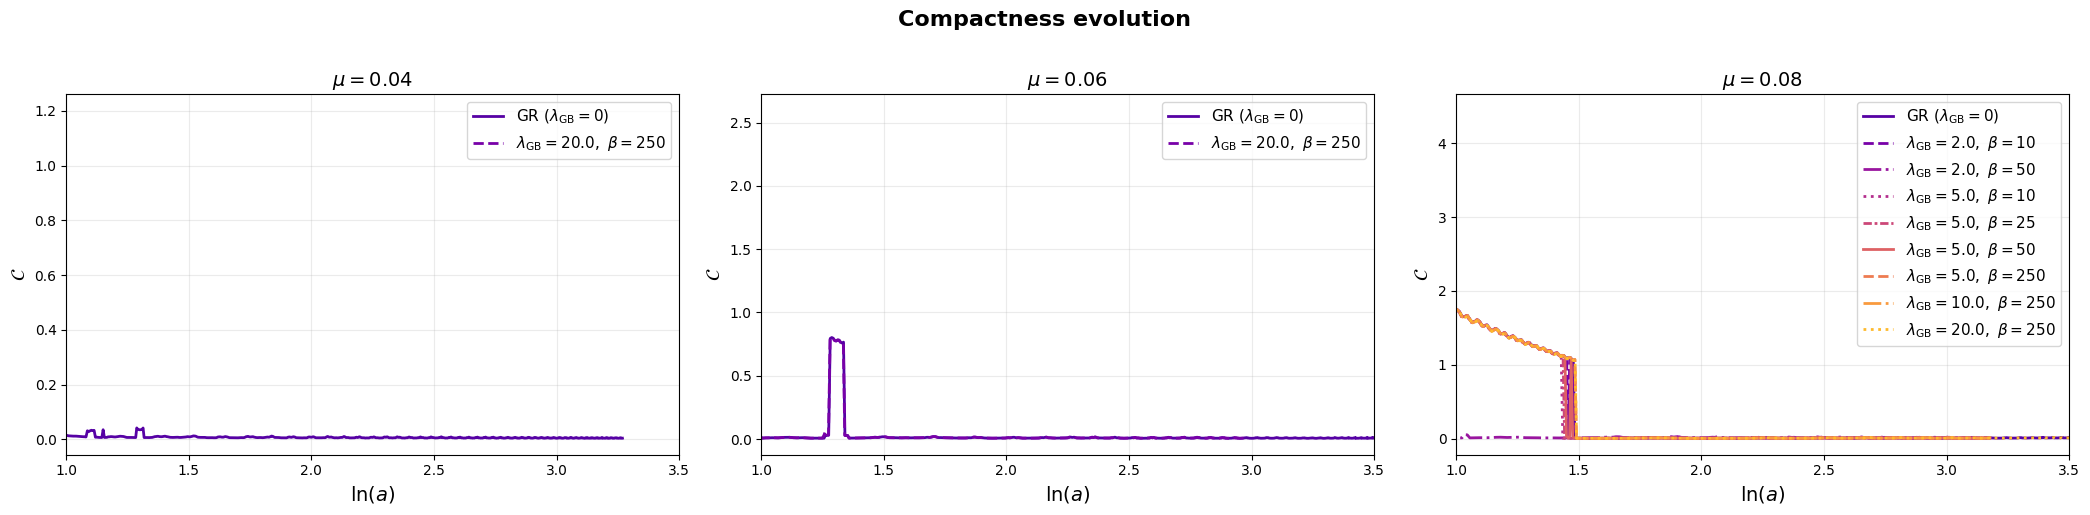

In [36]:
# Compactness time series for all (lgb, mu, beta) combinations
mu_values = sorted(set(mu for _, mu, _ in all_results.keys()))
lgb_beta_values = sorted(set((lgb, beta) for lgb, _, beta in all_results.keys()))

fig, axes = plt.subplots(1, len(mu_values), figsize=(7 * len(mu_values), 5), squeeze=False)

colors = plt.cm.plasma(np.linspace(0.15, 0.85, max(len(lgb_beta_values), 2)))
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

for col, mu in enumerate(mu_values):
    ax = axes[0, col]
    idx = 0
    for lgb, beta in lgb_beta_values:
        key = (lgb, mu, beta)
        if key not in all_results:
            continue
        osc = all_results[key]["osc"]
        if lgb == 0.0:
            label = r"GR ($\lambda_{\rm GB}=0$)"
        else:
            label = f"$\\lambda_{{\\rm GB}}={lgb},\\ \\beta={beta}$"
        ax.plot(osc["ln_a"], osc["C"],
                color=colors[idx % len(colors)], lw=2,
                linestyle=linestyles[idx % len(linestyles)], label=label)
        idx += 1

    ax.set_xlabel(r"$\ln(a)$", fontsize=14)
    ax.set_ylabel(r"$\mathcal{C}$", fontsize=14)
    ax.set_title(f"$\\mu = {mu}$", fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xlim(1, 3.5)
    ax.grid(True, alpha=0.25)

fig.suptitle("Compactness evolution", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

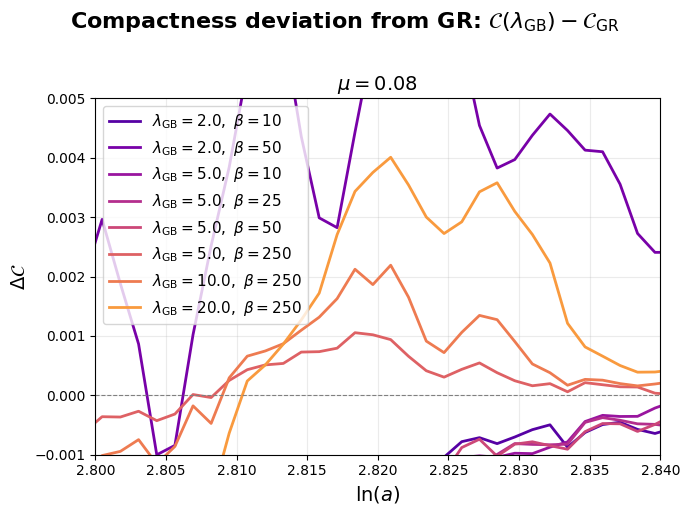

In [37]:
# Residual plot: C(lgb, mu, beta) - C(GR, mu) for each mu
mus = [0.08]

fig, axes = plt.subplots(1, len(mus), figsize=(7 * len(mus), 5), squeeze=False)

for col, mu in enumerate(mus):
    ax = axes[0, col]
    # Find GR baseline (lgb=0, any beta — beta is irrelevant for GR)
    gr_keys = [k for k in all_results if k[0] == 0.0 and k[1] == mu]
    if not gr_keys:
        ax.set_title(f"$\\mu = {mu}$ — no GR baseline", fontsize=14)
        continue

    gr_key = gr_keys[0]
    C_gr = all_results[gr_key]["osc"]["C"]
    ln_a_gr = all_results[gr_key]["osc"]["ln_a"]

    idx = 0
    for lgb, beta in lgb_beta_values:
        if lgb == 0.0:
            continue
        key = (lgb, mu, beta)
        if key not in all_results:
            continue
        osc = all_results[key]["osc"]
        C_mg = osc["C"]
        ln_a_mg = osc["ln_a"]
        if len(C_mg) != len(C_gr):
            C_mg = np.interp(ln_a_gr, ln_a_mg, C_mg)
        delta_C = C_mg - C_gr

        label = f"$\\lambda_{{\\rm GB}}={lgb},\\ \\beta={beta}$"
        ax.plot(ln_a_gr, delta_C,
                color=colors[idx % len(colors)], lw=2, label=label)
        idx += 1

    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel(r"$\ln(a)$", fontsize=14)
    ax.set_ylabel(r"$\Delta\mathcal{C}$", fontsize=14)
    ax.set_title(f"$\\mu = {mu}$", fontsize=14)
    ax.legend(fontsize=11)
    ax.set_xlim(2.8, 2.84)
    ax.set_ylim(-0.001, 5e-3)
    ax.grid(True, alpha=0.25)

fig.suptitle(r"Compactness deviation from GR: $\mathcal{C}(\lambda_{\rm GB}) - \mathcal{C}_{\rm GR}$",
             fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

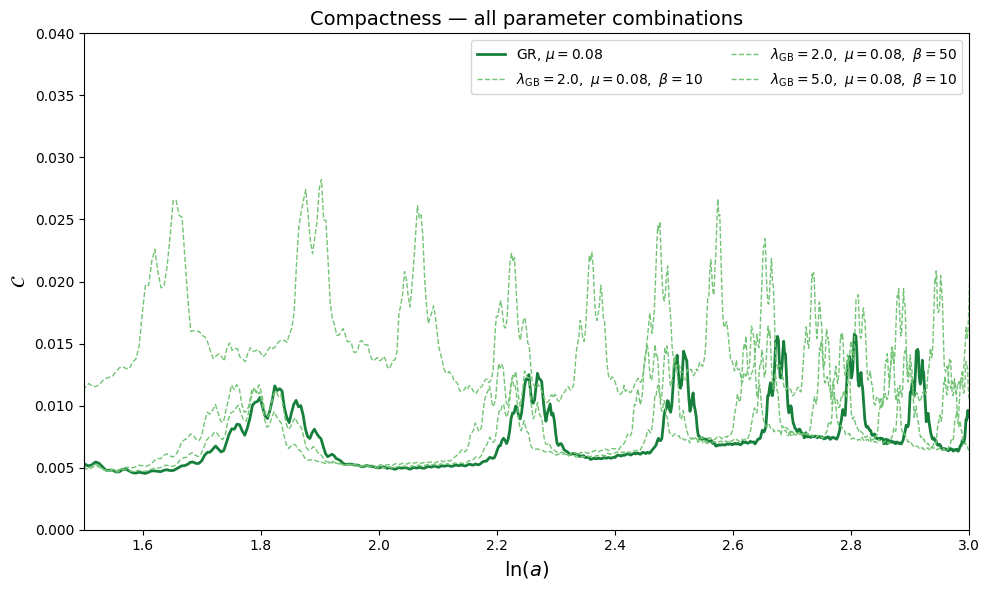

In [48]:
# All curves on a single plot for direct comparison
fig, ax = plt.subplots(figsize=(10, 6))

# One color family per mu — light for GR, dark for nonzero coupling
mu_values_plot = sorted(set(mu for _, mu, _ in all_results.keys()))
cmap_bases = [plt.cm.Blues, plt.cm.Reds, plt.cm.Greens, plt.cm.Purples, plt.cm.Oranges]
mu_base_cmap = {mu: cmap_bases[i % len(cmap_bases)] for i, mu in enumerate(mu_values_plot)}

skip_keys = {(5.0, 0.08, 250), (10, 0.08, 250), (20, 0.06, 250), (0, 0.06, 250), (20, 0.04, 250), (0, 0.04, 250)
,(5, 0.08, 25) ,(5, 0.08, 50),(20, 0.08, 250)}

for (lgb, mu, beta), data in sorted(all_results.items()):
    if (lgb, mu, beta) in skip_keys:
        continue
    osc = data["osc"]
    cmap = mu_base_cmap[mu]
    if lgb == 0.0:
        color = cmap(0.8)
        lw = 2
        label = f"GR, $\\mu={mu}$"
        ls = "-"
    else:
        color = cmap(0.5)
        lw = 1
        label = f"$\\lambda_{{\\rm GB}}={lgb},\\ \\mu={mu},\\ \\beta={beta}$"
        ls = "--"
    ax.plot(osc["ln_a"], osc["C"], color=color, lw=lw, ls=ls, label=label)

ax.set_xlabel(r"$\ln(a)$", fontsize=14)
ax.set_ylabel(r"$\mathcal{C}$", fontsize=14)
ax.set_title("Compactness — all parameter combinations", fontsize=14)
ax.legend(fontsize=10, ncol=2)
ax.set_xlim(1.5, 3)
ax.set_ylim(0, 0.04)
#ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()